In [ ]:
!pip install pandas numpy matplotlib seaborn openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [ ]:
import os

os.listdir()

['.config', 'Sample - Superstore.csv', 'sample_data']

In [ ]:
for file in os.listdir():
    print(file)

.config
Sample - Superstore.csv
sample_data


DATA LOADING

In [ ]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9994
Columns: 21


Dataset Overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Missing Values

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Duplicate Rows Check

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Numerical Summary

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


 Business Summary Metrics

In [ ]:
print("Total Sales:", round(df['Sales'].sum(),2))
print("Total Profit:", round(df['Profit'].sum(),2))
print("Total Orders:", df['Order ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793


Convert Date Columns

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("Date Conversion Successful")

Date Conversion Successful


Verify Conversion

In [ ]:
df[['Order Date','Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


 Create Time Features

In [ ]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()

print("Time Features Created")

Time Features Created


Verify New Columns

In [ ]:
df[['Order Date',
    'Order Year',
    'Order Month',
    'Order Month Name']].head()

,Order Date,Order Year,Order Month,Order Month Name
0,2016-11-08,2016,11,November
1,2016-11-08,2016,11,November
2,2016-06-12,2016,6,June
3,2015-10-11,2015,10,October
4,2015-10-11,2015,10,October


Category Overview

In [ ]:
print(df['Category'].value_counts())

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64


Region Overview

In [ ]:
print(df['Region'].value_counts())

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64


Segment Overview

In [ ]:
print(df['Segment'].value_counts())

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


Revenue Trend Intelligence

monthly sales table.

In [ ]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key='Order Date',
            freq='ME'
        )
    )['Sales']
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


cleaner month label

In [ ]:
print("Months Available:", len(monthly_sales))
monthly_sales['Month'] = monthly_sales['Order Date'].dt.strftime('%Y-%m')

monthly_sales.head()

Months Available: 48


,Order Date,Sales,Month
0,2014-01-31,14236.895,2014-01
1,2014-02-28,4519.892,2014-02
2,2014-03-31,55691.009,2014-03
3,2014-04-30,28295.345,2014-04
4,2014-05-31,23648.287,2014-05


strongest and weakest months.

In [ ]:
best_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmax()
]

worst_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmin()
]

print("Best Month")
print(best_month)

print("\nWorst Month")
print(worst_month)

Best Month
Order Date    2017-11-30 00:00:00
Sales                  118447.825
Month                     2017-11
Name: 46, dtype: object

Worst Month
Order Date    2014-02-28 00:00:00
Sales                    4519.892
Month                     2014-02
Name: 1, dtype: object


monthly growth.

In [ ]:
monthly_sales['Growth %'] = (
    monthly_sales['Sales']
    .pct_change()
    *100
)

monthly_sales.head()

,Order Date,Sales,Month,Growth %
0,2014-01-31,14236.895,2014-01,NaN
1,2014-02-28,4519.892,2014-02,-68.252263
2,2014-03-31,55691.009,2014-03,1132.131409
3,2014-04-30,28295.345,2014-04,-49.192257
4,2014-05-31,23648.287,2014-05,-16.423401


fastest growing month

In [ ]:
monthly_sales.sort_values(
    'Growth %',
    ascending=False
).head(5)

,Order Date,Sales,Month,Growth %
2,2014-03-31,55691.0090,2014-03,1132.131409
14,2015-03-31,38726.2520,2015-03,224.030794
8,2014-09-30,81777.3508,2014-09,193.009345
38,2017-03-31,58872.3528,2017-03,189.995399
10,2014-11-30,78628.7167,2014-11,149.984848


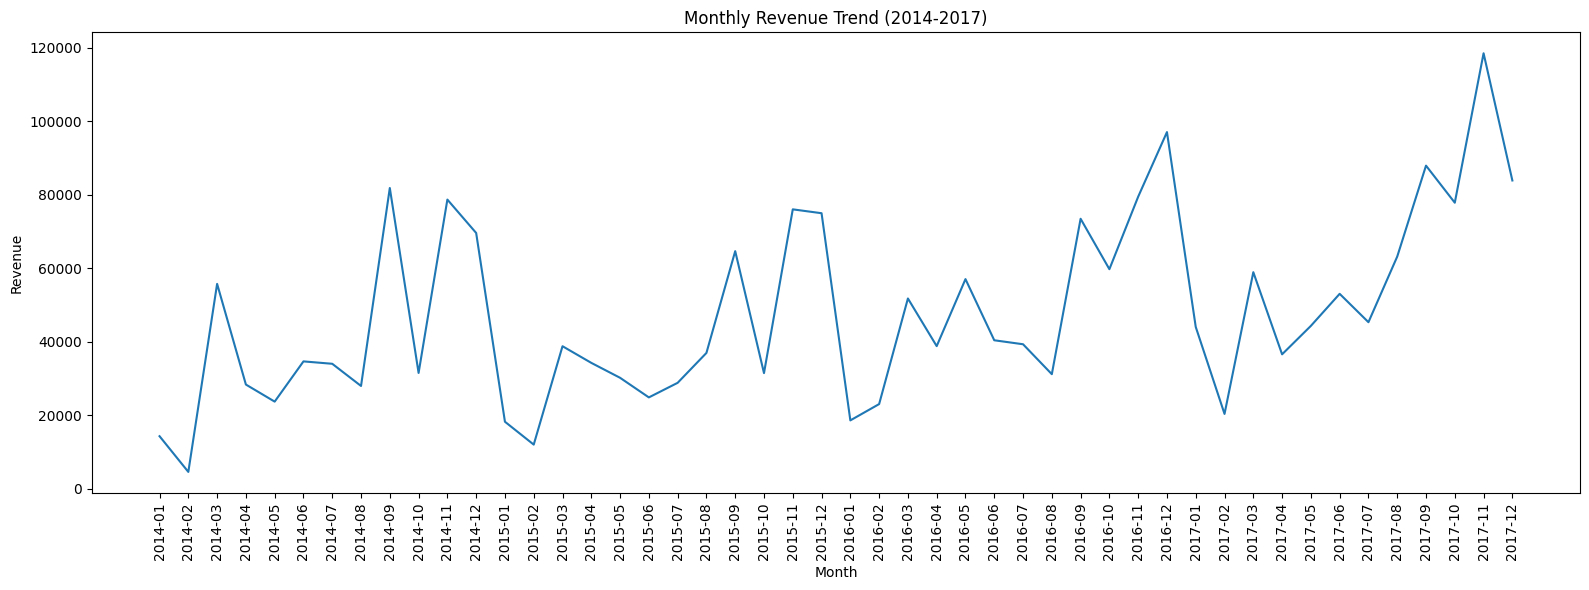

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    monthly_sales['Month'],
    monthly_sales['Sales']
)

plt.xticks(rotation=90)

plt.title(
    'Monthly Revenue Trend (2014-2017)'
)

plt.xlabel('Month')
plt.ylabel('Revenue')

plt.tight_layout()

plt.show()

PROFIT LEAKAGE ANALYSIS

most profit state

In [ ]:
state_profit = (
    df.groupby('State')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
      .round(2)
)

state_profit.sort_values(
    'Profit',
    ascending=False
).head(10)

,Sales,Profit
State,,
California,457687.63,76381.39
New York,310876.27,74038.55
Washington,138641.27,33402.65
Michigan,76269.61,24463.19
Virginia,70636.72,18597.95
Indiana,53555.36,18382.94
Georgia,49095.84,16250.04
Kentucky,36591.75,11199.70
Minnesota,29863.15,10823.19


states generate the biggest losses

In [ ]:
print("--- Monthly Sales Table ---")
print(monthly_sales.head().to_string())

print("\n--- Months Available and Monthly Sales with Month Label ---")
print("Months Available:", len(monthly_sales))
# This line ensures the 'Month' column is re-added if the kernel state changed or for reproduction clarity
monthly_sales['Month'] = monthly_sales['Order Date'].dt.strftime('%Y-%m')
print(monthly_sales.head().to_string())

print("\n--- Strongest and Weakest Months ---")
best_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmax()
]
worst_month = monthly_sales.loc[
    monthly_sales['Sales'].idxmin()
]
print("Best Month")
print(best_month.to_string())
print("\nWorst Month")
print(worst_month.to_string())

print("\n--- Monthly Growth ---")
monthly_sales['Growth %'] = (
    monthly_sales['Sales']
    .pct_change()
    *100
)
print(monthly_sales.head().to_string())

print("\n--- Fastest Growing Months ---")
print(monthly_sales.sort_values(
    'Growth %',
    ascending=False
).head(5).to_string())

# Skipping the plot output as it's a visual element.

print("\n--- Most Profitable States ---")
# Assuming state_profit DataFrame is already available in the kernel
print(state_profit.sort_values(
    'Profit',
    ascending=False
).head(10).to_string())

print("\n--- States with Biggest Losses ---")
print(state_profit.sort_values(
    'Profit'
).head(10).to_string())

print("\n--- Profit Margin Calculation ---")
state_profit['Profit Margin %'] = (
    state_profit['Profit']
    /
    state_profit['Sales']
)*100
print(state_profit.head().to_string())

print("\n--- Best Profit Margin States ---")
print(state_profit.sort_values(
    'Profit Margin %',
    ascending=False
).head(10).to_string())

--- Monthly Sales Table ---
  Order Date      Sales    Month     Growth %
0 2014-01-31  14236.895  2014-01          NaN
1 2014-02-28   4519.892  2014-02   -68.252263
2 2014-03-31  55691.009  2014-03  1132.131409
3 2014-04-30  28295.345  2014-04   -49.192257
4 2014-05-31  23648.287  2014-05   -16.423401

--- Months Available and Monthly Sales with Month Label ---
Months Available: 48
  Order Date      Sales    Month     Growth %
0 2014-01-31  14236.895  2014-01          NaN
1 2014-02-28   4519.892  2014-02   -68.252263
2 2014-03-31  55691.009  2014-03  1132.131409
3 2014-04-30  28295.345  2014-04   -49.192257
4 2014-05-31  23648.287  2014-05   -16.423401

--- Strongest and Weakest Months ---
Best Month
Order Date    2017-11-30 00:00:00
Sales                  118447.825
Month                     2017-11
Growth %                52.291734

Worst Month
Order Date    2014-02-28 00:00:00
Sales                    4519.892
Month                     2014-02
Growth %               -68.252263

---

Create Profit Margin

In [ ]:
state_profit['Profit Margin %'] = (
    state_profit['Profit']
    /
    state_profit['Sales']
)*100

state_profit.head()

,Sales,Profit,Profit Margin %
State,,,
Alabama,19510.64,5786.83,29.659868
Arizona,35282.00,-3427.92,-9.715776
Arkansas,11678.13,4008.69,34.326472
California,457687.63,76381.39,16.688541
Colorado,32108.12,-6527.86,-20.330870


Best Profit Margin States

In [ ]:
state_profit.sort_values(
    'Profit Margin %',
    ascending=False
).head(10)

,Sales,Profit,Profit Margin %
State,,,
District of Columbia,2865.02,1059.59,36.983686
Delaware,27451.07,9977.37,36.346015
Minnesota,29863.15,10823.19,36.242627
Maine,1270.53,454.49,35.771686
Arkansas,11678.13,4008.69,34.326472
Indiana,53555.36,18382.94,34.325117
Georgia,49095.84,16250.04,33.098609
Montana,5589.35,1833.33,32.800415
Rhode Island,22627.96,7285.63,32.197467


Worst Profit Margin States

In [ ]:
state_profit.sort_values(
    'Profit Margin %'
).head(10)

,Sales,Profit,Profit Margin %
State,,,
Ohio,78258.14,-16971.38,-21.686409
Colorado,32108.12,-6527.86,-20.330870
Tennessee,30661.87,-5341.69,-17.421279
Illinois,80166.10,-12607.89,-15.727209
Texas,170188.05,-25729.36,-15.118194
North Carolina,55603.16,-7490.91,-13.472094
Pennsylvania,116511.91,-15559.96,-13.354824
Arizona,35282.00,-3427.92,-9.715776
Oregon,17431.15,-1190.47,-6.829555


DISCOUNT INTELLIGENCE & PROFIT DESTRUCTION ANALYSIS

Understand Discount Structure

In [ ]:
df['Discount'].value_counts().sort_index()

,count
Discount,
0.00,4798
0.10,94
0.15,52
0.20,3657
0.30,227
0.32,27
0.40,206
0.45,11
0.50,66


Average Profit by Discount Level

In [ ]:
discount_profit = (
    df.groupby('Discount')
      .agg({
          'Sales':'mean',
          'Profit':'mean'
      })
      .round(2)
)

discount_profit

,Sales,Profit
Discount,,
0.00,226.74,66.90
0.10,578.40,96.06
0.15,529.97,27.29
0.20,209.08,24.70
0.30,454.74,-45.68
0.32,536.79,-88.56
0.40,565.13,-111.93
0.45,498.63,-226.65
0.50,892.71,-310.70


Average Profit by Discount Level

In [ ]:
discount_analysis = (
    df.groupby('Discount')
      .agg(
          Orders=('Order ID','count'),
          Avg_Sales=('Sales','mean'),
          Avg_Profit=('Profit','mean')
      )
      .round(2)
)

discount_analysis

,Orders,Avg_Sales,Avg_Profit
Discount,,,
0.00,4798,226.74,66.90
0.10,94,578.40,96.06
0.15,52,529.97,27.29
0.20,3657,209.08,24.70
0.30,227,454.74,-45.68
0.32,27,536.79,-88.56
0.40,206,565.13,-111.93
0.45,11,498.63,-226.65
0.50,66,892.71,-310.70


Correlation Analysis

In [ ]:
correlation = df[['Discount','Profit']].corr()

correlation

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


Identify Dangerous Discount Levels

In [ ]:
discount_analysis.sort_values(
    'Avg_Profit'
)

,Orders,Avg_Sales,Avg_Profit
Discount,,,
0.50,66,892.71,-310.70
0.45,11,498.63,-226.65
0.40,206,565.13,-111.93
0.80,300,56.55,-101.80
0.70,418,97.18,-95.87
0.32,27,536.79,-88.56
0.30,227,454.74,-45.68
0.60,138,48.15,-43.08
0.20,3657,209.08,24.70


State Discount Analysis

In [ ]:
state_discount = (
    df.groupby('State')
      .agg({
          'Discount':'mean',
          'Profit':'sum'
      })
      .round(3)
)

state_discount.sort_values(
    'Discount',
    ascending=False
).head(15)

,Discount,Profit
State,,
Illinois,0.390,-12607.887
Texas,0.370,-25729.356
Pennsylvania,0.329,-15559.960
Ohio,0.325,-16971.377
Colorado,0.316,-6527.858
Arizona,0.304,-3427.925
Florida,0.299,-3399.302
Tennessee,0.291,-5341.694
Oregon,0.289,-1190.470


Compare Texas vs California

In [ ]:
df[df['State'].isin(
    ['Texas','California']
)].groupby('State').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Discount':'mean'
}).round(2)

,Sales,Profit,Discount
State,,,
California,457687.63,76381.39,0.07
Texas,170188.05,-25729.36,0.37


PRODUCT PORTFOLIO INTELLIGENCE

Top Revenue Products

In [ ]:
top_sales_products = (
    df.groupby('Product Name')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
      .sort_values(
          'Sales',
          ascending=False
      )
)

top_sales_products.head(15)

,Sales,Profit
Product Name,,
Canon imageCLASS 2200 Advanced Copier,61599.8240,2.519993e+04
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.3840,7.753039e+03
Cisco TelePresence System EX90 Videoconferencing Unit,22638.4800,-1.811078e+03
HON 5400 Series Task Chairs for Big and Tall,21870.5760,5.684342e-14
GBC DocuBind TL300 Electric Binding System,19823.4790,2.233505e+03
GBC Ibimaster 500 Manual ProClick Binding System,19024.5000,7.609800e+02
Hewlett Packard LaserJet 3310 Copier,18839.6860,6.983884e+03
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.8950,4.094977e+03
GBC DocuBind P400 Electric Binding System,17965.0680,-1.878166e+03


Top Profit Products

In [ ]:
top_profit_products = (
    df.groupby('Product Name')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
      .sort_values(
          'Profit',
          ascending=False
      )
)

top_profit_products.head(15)

,Sales,Profit
Product Name,,
Canon imageCLASS 2200 Advanced Copier,61599.824,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,7753.0390
Hewlett Packard LaserJet 3310 Copier,18839.686,6983.8836
Canon PC1060 Personal Laser Copier,11619.834,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895,4094.9766
Ativa V4110MDD Micro-Cut Shredder,7699.890,3772.9461
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890,3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System,9367.290,3696.2820
Ibico EPK-21 Electric Binding System,15875.916,3345.2823


Biggest Loss-Making Products

In [ ]:
loss_products = (
    df.groupby('Product Name')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
      .sort_values(
          'Profit'
      )
)

loss_products.head(15)

,Sales,Profit
Product Name,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836
Balt Solid Wood Round Tables,6518.754,-1201.0581


Create Product Margin Table

In [ ]:
product_analysis = (
    df.groupby('Product Name')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
)

product_analysis['Profit Margin %'] = (
    product_analysis['Profit']
    /
    product_analysis['Sales']
) * 100

product_analysis.head()

,Sales,Profit,Profit Margin %
Product Name,,,
"""While you Were Out"" Message Book, One Form per Page",25.228,10.3880,41.176471
"#10 Gummed Flap White Envelopes, 100/Box",41.300,16.7678,40.600000
#10 Self-Seal White Envelopes,108.682,52.1230,47.959184
"#10 White Business Envelopes,4 1/8 x 9 1/2",488.904,223.1408,45.641026
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,115.2806,40.213415


High Revenue but Low Profit Products

In [ ]:
high_revenue_low_profit = (
    product_analysis[
        (product_analysis['Sales'] > product_analysis['Sales'].quantile(0.90))
        &
        (product_analysis['Profit'] < product_analysis['Profit'].median())
    ]
    .sort_values(
        'Sales',
        ascending=False
    )
)

high_revenue_low_profit.head(20)

,Sales,Profit,Profit Margin %
Product Name,,,
Cisco TelePresence System EX90 Videoconferencing Unit,22638.4800,-1.811078e+03,-8.000000e+00
HON 5400 Series Task Chairs for Big and Tall,21870.5760,5.684342e-14,2.599082e-16
GBC DocuBind P400 Electric Binding System,17965.0680,-1.878166e+03,-1.045455e+01
High Speed Automatic Electric Letter Opener,17030.3120,-2.620048e+02,-1.538462e+00
Lexmark MX611dhe Monochrome Laser Printer,16829.9010,-4.589973e+03,-2.727273e+01
Martin Yale Chadless Opener Electric Letter Opener,16656.2000,-1.299184e+03,-7.800000e+00
"Riverside Palais Royal Lawyers Bookcase, Royale Cherry Finish",15610.9656,-6.695448e+02,-4.288939e+00
Bretford Rectangular Conference Table Tops,12995.2915,-3.272331e+02,-2.518090e+00
Cubify CubeX 3D Printer Double Head Print,11099.9630,-8.879970e+03,-8.000000e+01


Revenue Concentration Risk

In [ ]:
top20_sales = (
    product_analysis
      .sort_values(
          'Sales',
          ascending=False
      )
      .head(20)
)

top20_share = (
    top20_sales['Sales'].sum()
    /
    df['Sales'].sum()
) * 100

print(
    f"Top 20 Products Revenue Share: {top20_share:.2f}%"
)

Top 20 Products Revenue Share: 16.91%


Product Profitability Segmentation

In [ ]:
print("Profitable Products:",
      (product_analysis['Profit'] > 0).sum())

print("Loss Making Products:",
      (product_analysis['Profit'] < 0).sum())

Profitable Products: 1546
Loss Making Products: 301


SUB-CATEGORY INTELLIGENCE

Revenue by Sub-Category

In [ ]:
subcategory_sales = (
    df.groupby('Sub-Category')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
      .sort_values(
          'Sales',
          ascending=False
      )
)

subcategory_sales

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


Top Revenue Sub-Categories

In [ ]:
subcategory_sales.head(10)

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


Profit by Sub-Category

In [ ]:
subcategory_sales.sort_values(
    'Profit',
    ascending=False
).head(10)

,Sales,Profit
Sub-Category,,
Copiers,149528.030,55617.8249
Phones,330007.054,44515.7306
Accessories,167380.318,41936.6357
Paper,78479.206,34053.5693
Binders,203412.733,30221.7633
Chairs,328449.103,26590.1663
Storage,223843.608,21278.8264
Appliances,107532.161,18138.0054
Furnishings,91705.164,13059.1436


Loss-Making Sub-Categories

In [ ]:
subcategory_sales.sort_values(
    'Profit'
).head(10)

,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436


Profit Margin Analysis

In [ ]:
subcategory_analysis = (
    df.groupby('Sub-Category')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
)

subcategory_analysis['Profit Margin %'] = (
    subcategory_analysis['Profit']
    /
    subcategory_analysis['Sales']
)*100

subcategory_analysis

,Sales,Profit,Profit Margin %
Sub-Category,,,
Accessories,167380.3180,41936.6357,25.054700
Appliances,107532.1610,18138.0054,16.867517
Art,27118.7920,6527.7870,24.071083
Binders,203412.7330,30221.7633,14.857361
Bookcases,114879.9963,-3472.5560,-3.022768
Chairs,328449.1030,26590.1663,8.095673
Copiers,149528.0300,55617.8249,37.195585
Envelopes,16476.4020,6964.1767,42.267582
Fasteners,3024.2800,949.5182,31.396504


Best Margin Sub-Categories

In [ ]:
subcategory_analysis.sort_values(
    'Profit Margin %',
    ascending=False
)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Labels,12486.3120,5546.2540,44.418672
Paper,78479.2060,34053.5693,43.391837
Envelopes,16476.4020,6964.1767,42.267582
Copiers,149528.0300,55617.8249,37.195585
Fasteners,3024.2800,949.5182,31.396504
Accessories,167380.3180,41936.6357,25.054700
Art,27118.7920,6527.7870,24.071083
Appliances,107532.1610,18138.0054,16.867517
Binders,203412.7330,30221.7633,14.857361


Revenue vs Profit Matrix

In [ ]:
subcategory_matrix = (
    df.groupby('Sub-Category')
      .agg({
          'Sales':'sum',
          'Profit':'sum'
      })
      .round(2)
)

subcategory_matrix

,Sales,Profit
Sub-Category,,
Accessories,167380.32,41936.64
Appliances,107532.16,18138.01
Art,27118.79,6527.79
Binders,203412.73,30221.76
Bookcases,114880.00,-3472.56
Chairs,328449.10,26590.17
Copiers,149528.03,55617.82
Envelopes,16476.40,6964.18
Fasteners,3024.28,949.52


Portfolio Classification

In [ ]:
print(
    "Revenue-Producing Sub-Categories:",
    len(subcategory_matrix)
)

Revenue-Producing Sub-Categories: 17


Revenue Concentration

In [ ]:
top5_subcategories = (
    subcategory_analysis
      .sort_values(
          'Sales',
          ascending=False
      )
      .head(5)
)

share = (
    top5_subcategories['Sales'].sum()
    /
    df['Sales'].sum()
)*100

print(
    f"Top 5 Sub-Categories Revenue Share: {share:.2f}%"
)

Top 5 Sub-Categories Revenue Share: 56.27%


Customer Segment Intelligence

In [ ]:
segment_analysis = (
    df.groupby('Segment')
      .agg({
          'Sales':'sum',
          'Profit':'sum',
          'Customer ID':'nunique'
      })
      .rename(columns={
          'Customer ID':'Unique Customers'
      })
)

segment_analysis['Profit Margin %'] = (
    segment_analysis['Profit']
    /
    segment_analysis['Sales']
)*100

segment_analysis.round(2)

,Sales,Profit,Unique Customers,Profit Margin %
Segment,,,,
Consumer,1161401.34,134119.21,409,11.55
Corporate,706146.37,91979.13,236,13.03
Home Office,429653.15,60298.68,148,14.03


# Strategic Business Recommendations


### Recommendation 1: Reduce High Discounting

* Restrict discounts above 30%.
* Require approval for large discount campaigns.
* Monitor profitability impact before increasing discount levels

### Recommendation 2 Expand Home Office Customer Acquisition


* Create targeted marketing campaigns for Home Office customers.
* Offer business-focused product bundles.
* Develop loyalty programs for this segment




### Recommendation 3: Expand Copier Sales

* Increase marketing focus on copiers.
* Maintain adequate inventory levels.
* Create promotional campaigns centered on copier products.

### Recommendation 4: Focus on High-Margin Products

* Increase visibility of high-margin products.
* Bundle them with other purchases.
* Promote them through targeted campaigns.

### Recommendation 5: Improve Performance in Loss-Making States

* Investigate pricing strategies in loss-making states.
* Review regional discount policies.
* Analyze logistics and shipping costs

# **Summary**

* Total sales exceeded $2.29 million while total profit reached $286,397.
* Revenue growth showed strong seasonality, with November consistently being the strongest sales month.
* Discounts above 30% were strongly associated with negative profitability.
* Texas, Ohio, Pennsylvania, and Illinois were the largest loss-making states.
* Copiers were the most profitable sub-category, generating over $55,000 profit with a margin above 37%.
* Tables represented the largest profitability concern, producing substantial losses despite strong revenue.
* Home Office customers generated the highest profit margin among customer segments.
* The product portfolio was generally healthy, with approximately 84% of products remaining profitable.

* DATA LOADING
* Dataset Overview
* Missing Values
* Duplicate Rows Check
* Numerical Summary
* Business Summary Metrics
* Convert Date Columns
* Verify Conversion
* Create Time Features
* Verify New Columns
* Category Overview
* Region Overview
* Segment Overview
* Revenue Trend Intelligence
* monthly sales table.
* cleaner month label
* strongest and weakest months.
* monthly growth.
* fastest growing month
* PROFIT LEAKAGE ANALYSIS
* most profit state
* states generate the biggest losses
* Create Profit Margin
* Best Profit Margin States
* Worst Profit Margin States
* DISCOUNT INTELLIGENCE & PROFIT DESTRUCTION ANALYSIS
* Understand Discount Structure
* Average Profit by Discount Level
* Average Profit by Discount Level
* Correlation Analysis
* Identify Dangerous Discount Levels
* State Discount Analysis
* Compare Texas vs California
* PRODUCT PORTFOLIO INTELLIGENCE
* Top Revenue Products
* Top Profit Products
* Biggest Loss-Making Products
* Create Product Margin Table
* High Revenue but Low Profit Products
* Revenue Concentration Risk
* Product Profitability Segmentation
* SUB-CATEGORY INTELLIGENCE
* Revenue by Sub-Category
* Top Revenue Sub-Categories
* Profit by Sub-Category
* Loss-Making Sub-Categories
* Profit Margin Analysis
* Best Margin Sub-Categories
* Revenue vs Profit Matrix
* Portfolio Classification
* Revenue Concentration
* Customer Segment Intelligence